In [14]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import sys  
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution

sys.path.append("../../")
from utils.nplm_postproc import extract_tstat, get_statistics, get_statistics_npy
import utils.plotting as plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# CIFAR-10 w/o class 1, class 1 = anomaly; testing with CIFAR-5m

In [15]:
# hyper parameters of the NPLM model
M=100 # number of kernels
flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing

# files containing the toys for different physics assumptions
# keep 'ref' as key for the calibraiton toys for consistence
base_dir = "../experiments_output/cifar10_anom1_v2/M100_lam1e-07_iter10000000_sigma0.1-1.5-2.6-3.6-4.9-9.8-_NoPois/"
files_dict = {
    #'ref': f"{base_dir}/Nref8000_Nbkg1000_refOnly/tests_all.h5",
    'ref': f"{base_dir}/Nref9000_Nbkg1800/tests_all.h5",
    0.01: f"{base_dir}/Nref9000_Nbkg1800_Nsig18/tests_all.h5",
    0.02: f"{base_dir}/Nref9000_Nbkg1800_Nsig36/tests_all.h5",
    0.05: f"{base_dir}/Nref9000_Nbkg1800_Nsig90/tests_all.h5",
    0.1: f"{base_dir}/Nref9000_Nbkg1800_Nsig180/tests_all.h5",
    0.2: f"{base_dir}/Nref9000_Nbkg1800_Nsig360/tests_all.h5",
}
# key values extraction
files = list(files_dict.values())
labels_list = list(files_dict.keys())
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

NTOYS = 500
tstats_nplm = extract_tstat(files_dict, flk_sigmas, NTOYS=NTOYS)
statistics_nplm = get_statistics(tstats_nplm, flk_sigmas)
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

pvalues = statistics_nplm['pvalues']
pvalues_min = statistics_nplm['pvalues_min']
pvalues_avg = statistics_nplm['pvalues_avg']
pvalues_prod = statistics_nplm['pvalues_prod']
z_obs = statistics_nplm['z_obs']
z_obs_p = statistics_nplm['z_obs_p']
z_obs_m = statistics_nplm['z_obs_m']
z_emp = statistics_nplm['z_emp']
z_emp_p = statistics_nplm['z_emp_p']
z_emp_m = statistics_nplm['z_emp_m']
z_min = statistics_nplm['z_min']
z_avg = statistics_nplm['z_avg']
z_prod = statistics_nplm['z_prod']

ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/cifar10/cifar10SpaceWithoutClass1_T0.1_idealZscores_LRtestWithFit_nbkg1.8k_anomClass1_trainedCIFAR10.npz")
double_ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/cifar10/cifar10AllClassSpace_T0.1_idealZscores_LRtestWithFit_nbkg1.8k_anomClass1_trainedCIFAR10.npz")
maha_emp_zscores = np.load("/n/home11/sambt/phlab-neurips25/nplm/notebooks_maha/cifar10_maha_empiricalZscore.npz")

# FID scores
fid_path = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_anom1_v2/FID_NoPois/"
files_dict_fid = {
    'ref': fid_path + "Nref9000_Nbkg1800_Nsig0/test_all.npy",
    0.01: fid_path + "Nref9000_Nbkg1800_Nsig18/test_all.npy",
    0.02: fid_path + "Nref9000_Nbkg1800_Nsig36/test_all.npy",
    0.05: fid_path + "Nref9000_Nbkg1800_Nsig90/test_all.npy",
    0.1: fid_path + "Nref9000_Nbkg1800_Nsig180/test_all.npy",
    0.2: fid_path + "Nref9000_Nbkg1800_Nsig360/test_all.npy"
}
tstats_fid = extract_tstat(files_dict_fid, flk_sigmas, NTOYS=NTOYS, ftype='npy')
statistics_fid = get_statistics_npy(tstats_fid)
inj_fractions_fid = sorted([k for k in files_dict_fid.keys() if k != 'ref'])

# MMD scores
mmd_path = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_anom1_v2/NysMMD_M103_NoPois/"
files_dict_mmd = {
    'ref': mmd_path + "Nref9000_Nbkg1800_Nsig0/test_all.npy",
    0.01: mmd_path + "Nref9000_Nbkg1800_Nsig18/test_all.npy",
    0.02: mmd_path + "Nref9000_Nbkg1800_Nsig36/test_all.npy",
    0.05: mmd_path + "Nref9000_Nbkg1800_Nsig90/test_all.npy",
    0.1: mmd_path + "Nref9000_Nbkg1800_Nsig180/test_all.npy",
    0.2: mmd_path + "Nref9000_Nbkg1800_Nsig360/test_all.npy"
}
tstats_mmd = extract_tstat(files_dict_mmd, flk_sigmas, NTOYS=NTOYS, ftype='npy')
statistics_mmd = get_statistics_npy(tstats_mmd)
inj_fractions_mmd = sorted([k for k in files_dict_mmd.keys() if k != 'ref'])

## plot Z scores

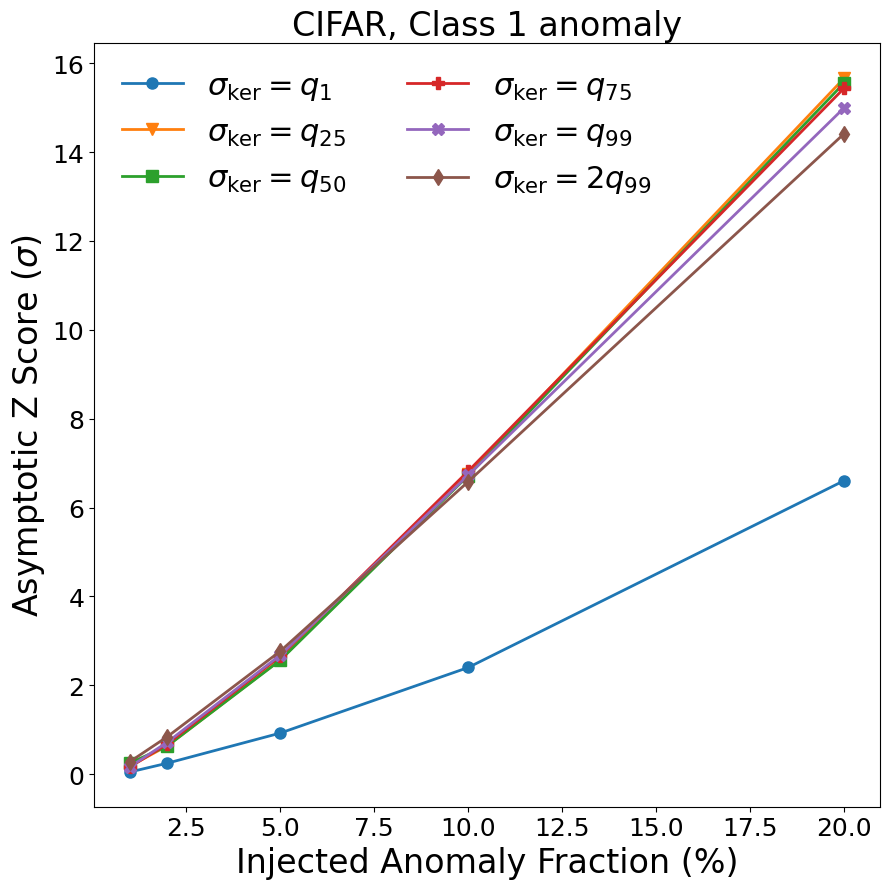

In [7]:
plt.figure(figsize=(9,9))
plt.title("CIFAR, Class 1 anomaly",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_obs[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.xscale('log')
xlim = plt.gca().get_xlim()
#plt.plot(x_values,[z_avg[f] for f in inj_fractions],lw=2, linestyle='-',marker=None,color="k",label=f"Average")
#plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],lw=2,linestyle='--',color='blue',label='Supervised')
#plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],lw=2,linestyle='--',color='crimson',label='Ideal Supervised')
#plt.xlim(xlim)
#plt.xlim([0.5,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Asymptotic Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
#plt.ylim([0,9])
plt.legend(ncol=2,fontsize=22,frameon=False)
plt.tight_layout()
plt.savefig("cifar_plots/cifar10asymptoticZscores.pdf",bbox_inches='tight')

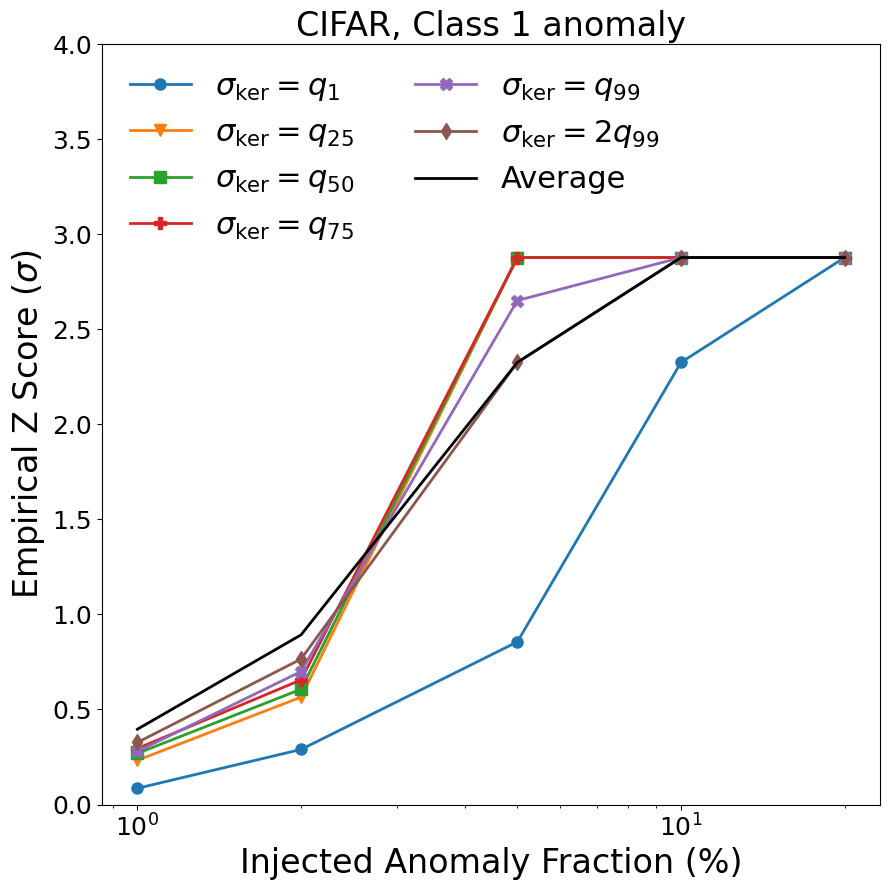

In [8]:
plt.figure(figsize=(9,9))
plt.title("CIFAR, Class 1 anomaly",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_emp[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.plot(x_values,[z_min[f] for f in inj_fractions],lw=2, marker=None,color="k",label=f"Min")
plt.plot(x_values,[z_avg[f] for f in inj_fractions],lw=2, linestyle='-',marker=None,color="k",label=f"Average")
#plt.plot(x_values,[z_prod[f] for f in inj_fractions],lw=2, linestyle='--',marker=None,color="k",label=f"Prod Aggregation")
plt.xscale('log')
xlim = plt.gca().get_xlim()
#plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],lw=2,linestyle='--',color='blue',label='Supervised')
#plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],lw=2,linestyle='--',color='crimson',label='Ideal Supervised')
#plt.xlim(xlim)
#plt.xlim([None,10])
plt.ylim([0,4])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Empirical Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=22,frameon=False,loc='upper left')
plt.tight_layout()
plt.savefig("cifar_plots/cifar10_empiricalZscores.pdf",bbox_inches='tight')

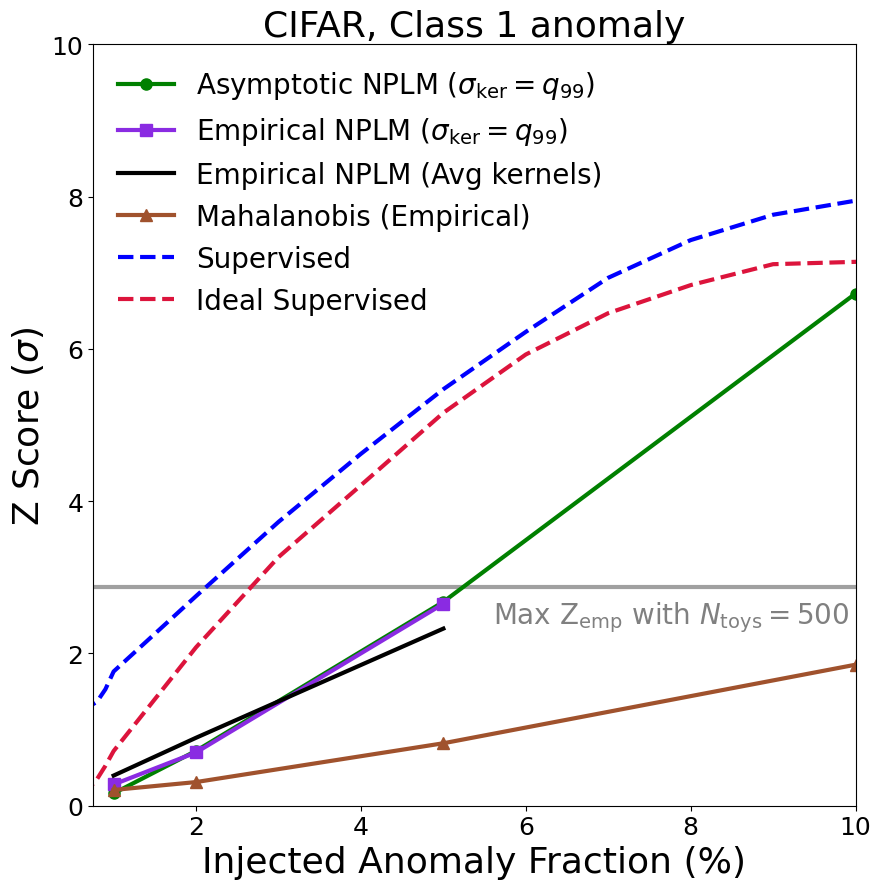

In [9]:
plt.figure(figsize=(9,9))
plt.title(r"CIFAR, Class 1 anomaly",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 4.9
isigma = flk_sigmas.index(best_sigma)
sigma_label = plotting.kernel_to_label[best_sigma]
handles_1=[]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:-2],y_values[:-2],lw=3,
         marker='s',markersize=8,color='blueviolet',
         #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

# avg empirical
l3,=plt.plot(x_values[:-2],[z_avg[f] for f in inj_fractions][:-2],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

# supervised
xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
# ideal supervised
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

plt.xlim(xlim)
plt.xlim([0.75,10])
plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=20,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(5.6,2.4,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("cifar_plots/cifar10_class1Anom_Zsummary.pdf")

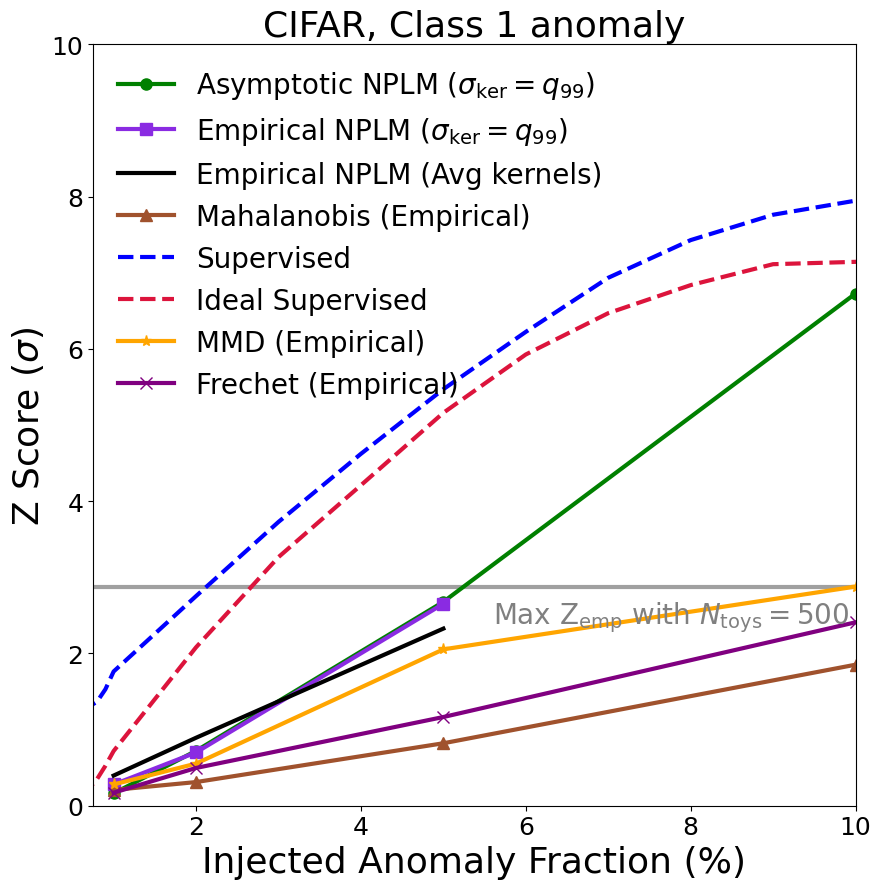

In [10]:
plt.figure(figsize=(9,9))
plt.title(r"CIFAR, Class 1 anomaly",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 4.9
isigma = flk_sigmas.index(best_sigma)
sigma_label = plotting.kernel_to_label[best_sigma]
handles_1=[]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:-2],y_values[:-2],lw=3,
         marker='s',markersize=8,color='blueviolet',
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

# avg empirical
l3,=plt.plot(x_values[:-2],[z_avg[f] for f in inj_fractions][:-2],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

# supervised
xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
# ideal supervised
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

# mmd
y_values = [statistics_mmd['z_emp'][f] for f in inj_fractions_mmd]
l8, = plt.plot(100*np.array(inj_fractions_mmd),y_values,lw=3,color='orange',label="MMD (Empirical)",
              marker='*',markersize=8)
handles_1.append(l8)

# Frechet
y_values = [statistics_fid['z_emp'][f] for f in inj_fractions_fid]
l9, = plt.plot(100*np.array(inj_fractions_fid),y_values,lw=3,color='purple',label="Frechet (Empirical)",
              marker='x',markersize=8)
handles_1.append(l9)

plt.xlim(xlim)
plt.xlim([0.75,10])
plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=20,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(5.6,2.4,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("cifar_plots/cifar10_class1Anom_Zsummary_withMMDFID.pdf")

# Visualize Spaces

In [19]:
base_dir = "/".join(files_dict[0.1].split("/")[:-1])
with open(f"{base_dir}/config.json","r") as fin:
    config = json.load(fin)

ref_data = np.load(config['ref_filepath'])
bkg_data = np.load(config['data_filepath'])
anom_label = config['anomaly_label']

ref_mask = ref_data['labels'] != anom_label
bkg_mask = bkg_data['labels'] != anom_label

ref = ref_data['data'][ref_mask]
ref_labels = ref_data['labels'][ref_mask]
bkg = bkg_data['data'][bkg_mask]
bkg_labels = bkg_data['labels'][bkg_mask]
anom = bkg_data['data'][~bkg_mask]
anom_labels = bkg_data['labels'][~bkg_mask]

/n/home11/sambt/phlab-neurips25/nplm/notebooks/../../utils/plotting.py:149: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  if return_fig:


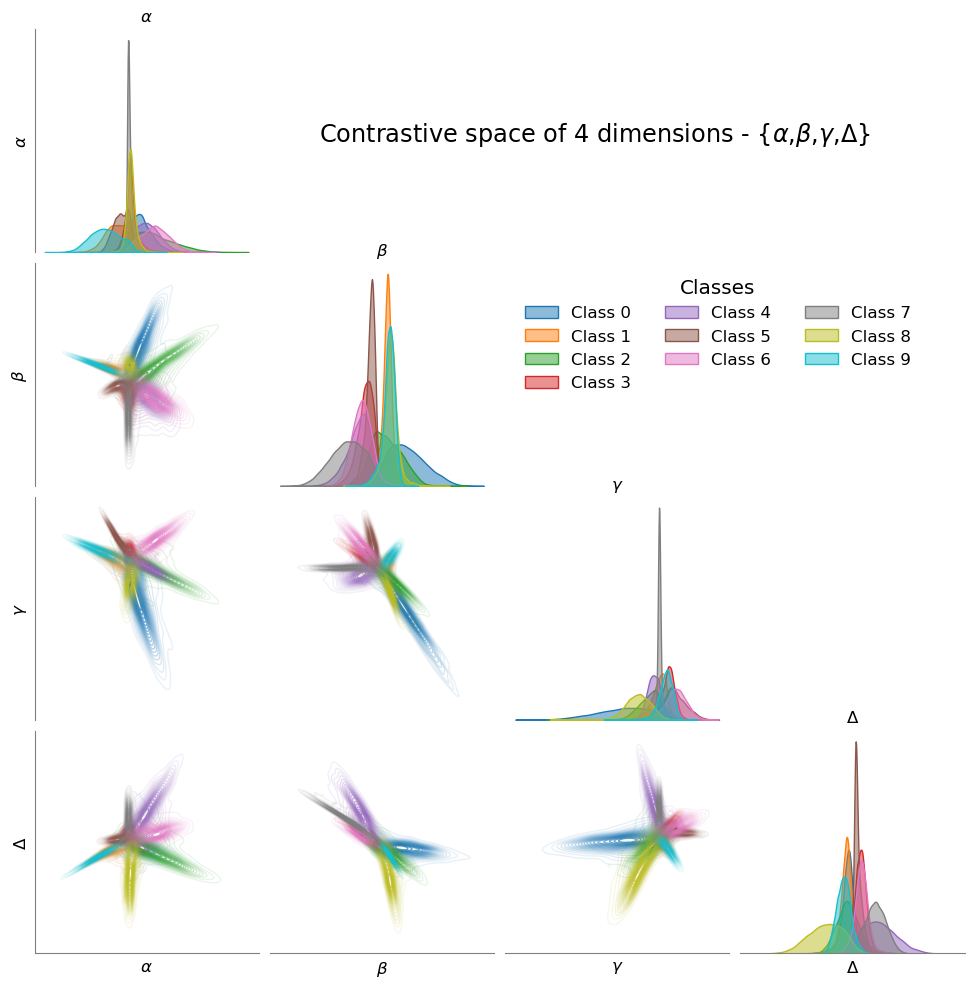

In [27]:
from plotting import make_corner2
nplot = 100_000
x = np.concatenate([bkg[:nplot],anom[:nplot]])
labels = np.concatenate([bkg_labels[:nplot],anom_labels[:nplot]])
shuf = np.random.permutation(len(x))
x = x[shuf]
labels = labels[shuf]
label_names = {i:f"Class {i}" for i in range(10)}
fig = make_corner2(x, labels, label_names=label_names, axwidth=3, return_fig=True, 
                kde=True, subsample=True, label_map=None)
fig.savefig("cifar10_space_100k.pdf")

# Differentiate CIFAR10 vs CIFAR5M or CIFAR10.1

In [11]:
flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing
files_dict = {
    "ref": "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_vs_cifar10_fullSpaceTrainingNoSignal/M100_lam1e-07_iter10000000_sigma0.1-1.5-2.6-3.6-4.9-9.8-_NoPois/Nref8500_Nbkg1500/tests_all.h5",
    "5m": "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_vs_cifar5m_fullSpaceTrainingNoSignal/M100_lam1e-07_iter10000000_sigma0.1-1.5-2.6-3.6-4.9-9.8-_NoPois/Nref8500_Nbkg1500/tests_all.h5",
    "101": "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_vs_cifar10.1_fullSpaceTrainingNoSignal/M100_lam1e-07_iter10000000_sigma0.1-1.5-2.6-3.6-4.9-9.8-_NoPois/Nref8500_Nbkg1500/tests_all.h5"
}
files = list(files_dict.values())
labels_list = list(files_dict.keys())
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

NTOYS = 500

tstat_dict = {}
i=0
for f5 in files:
    f = h5py.File(f5, 'r')
    if not len(flk_sigmas):
        flk_sigmas = list(f.keys())
    tstat_dict[labels_list[i]] = []
    for flk_sigma in flk_sigmas:
        key = str(flk_sigma) 
        tstat_dict[labels_list[i]].append(np.array(f[key])[:NTOYS].reshape(-1,1))
    tstat_dict[labels_list[i]] = np.concatenate(tstat_dict[labels_list[i]],axis=1)
    f.close()
    i+=1

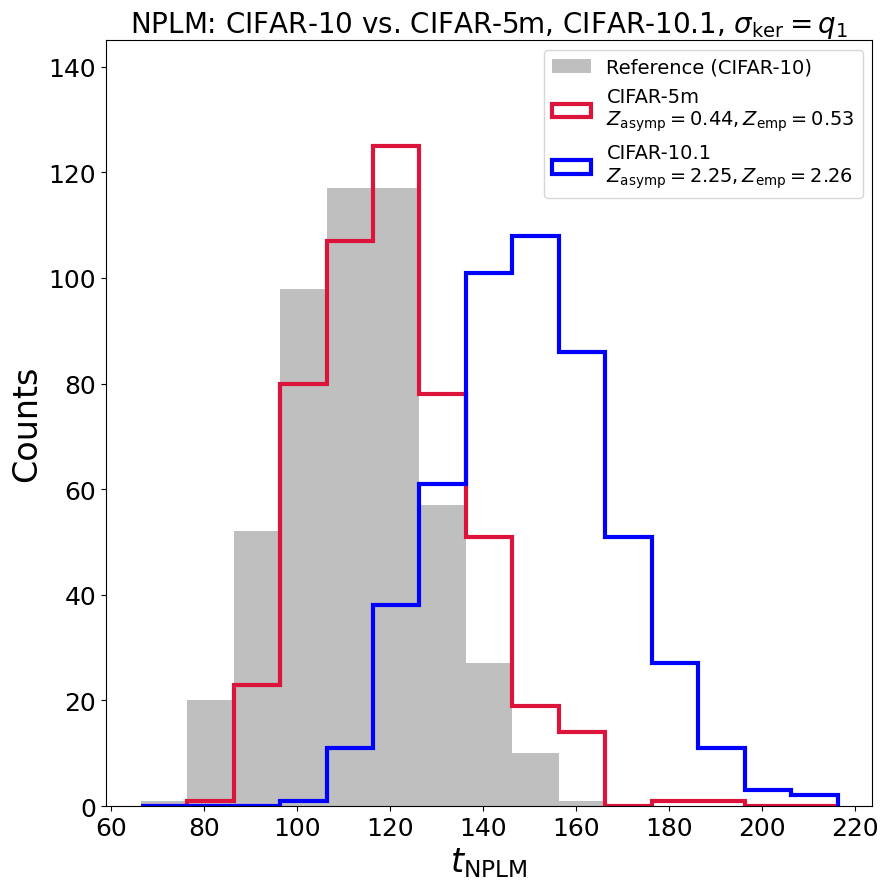

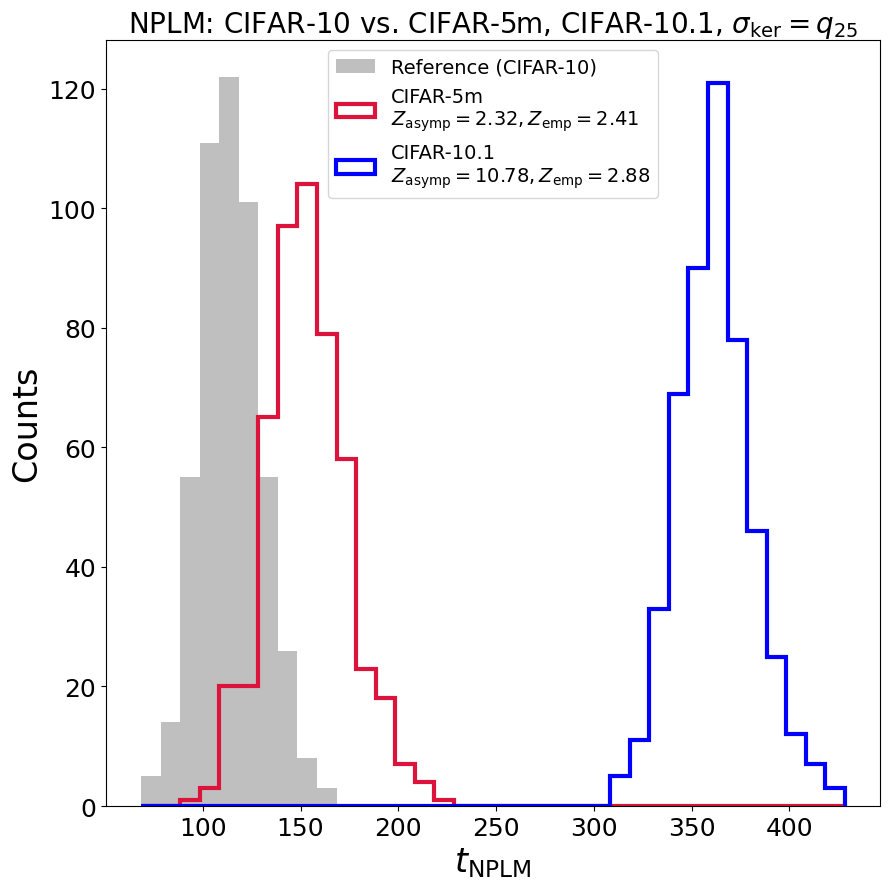

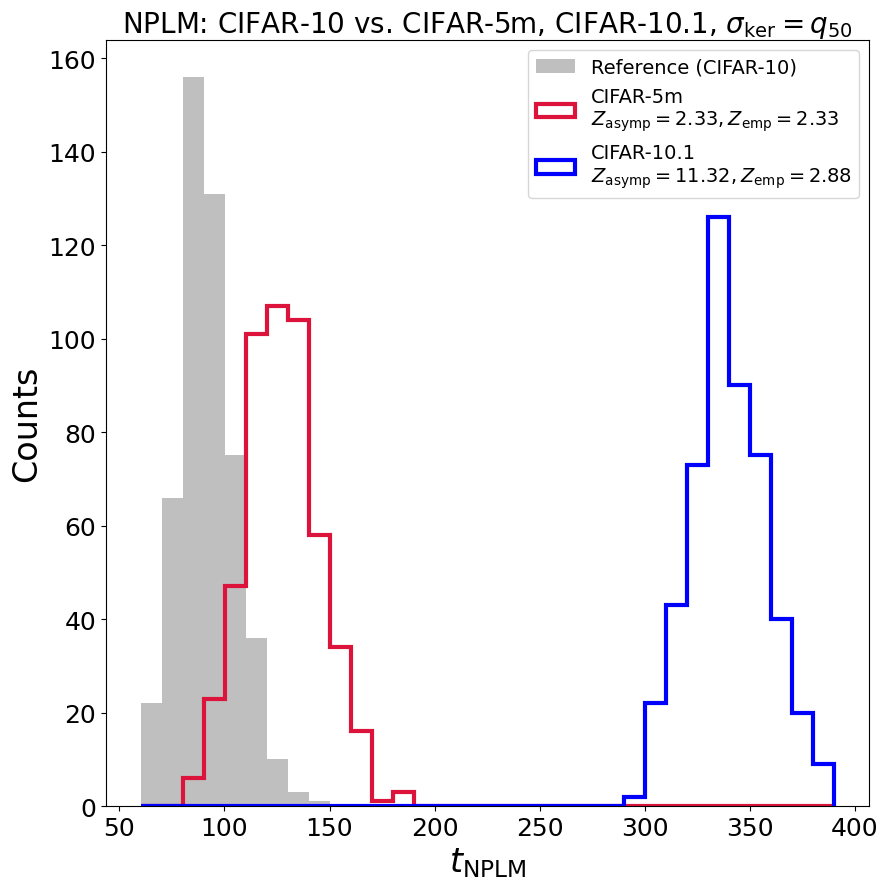

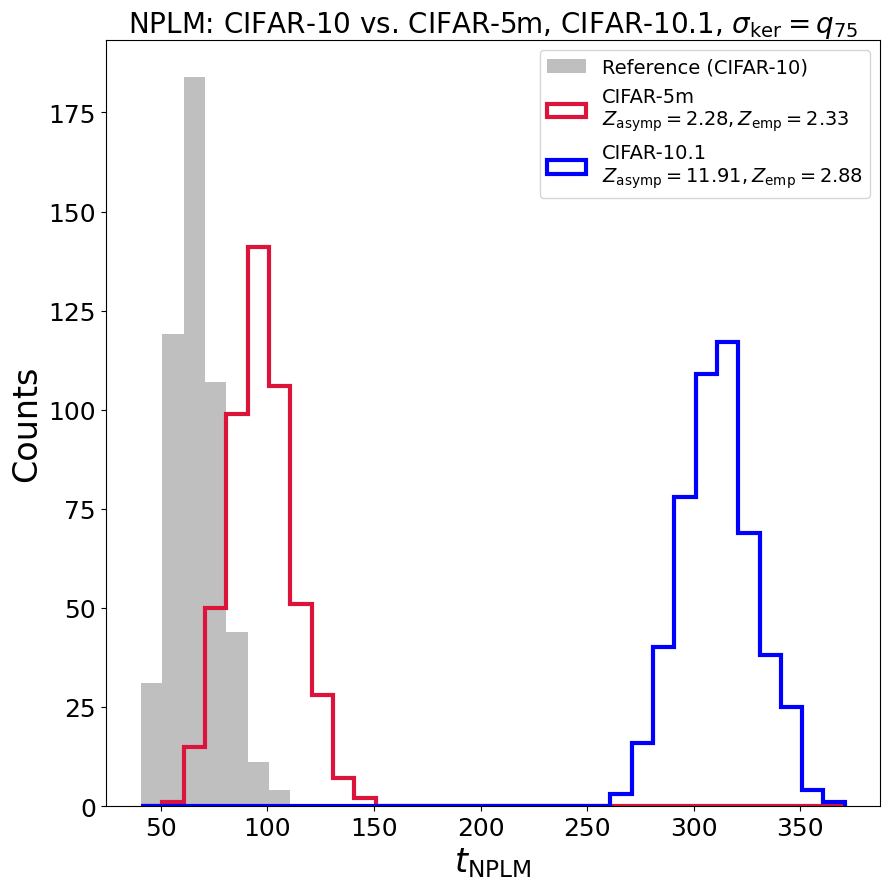

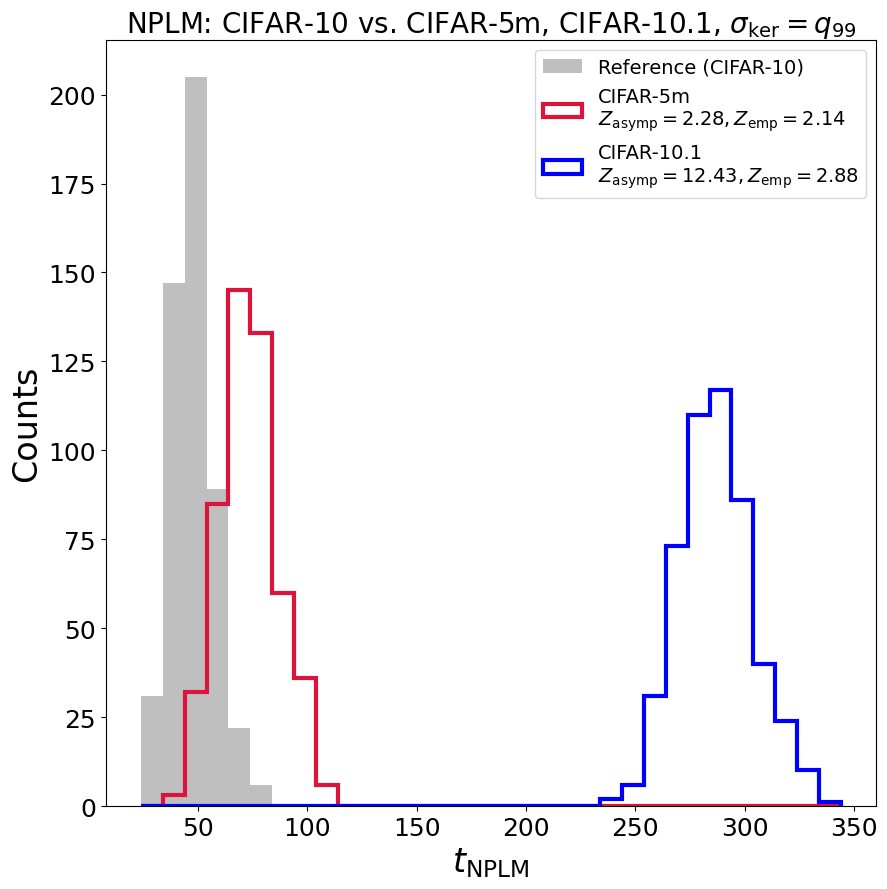

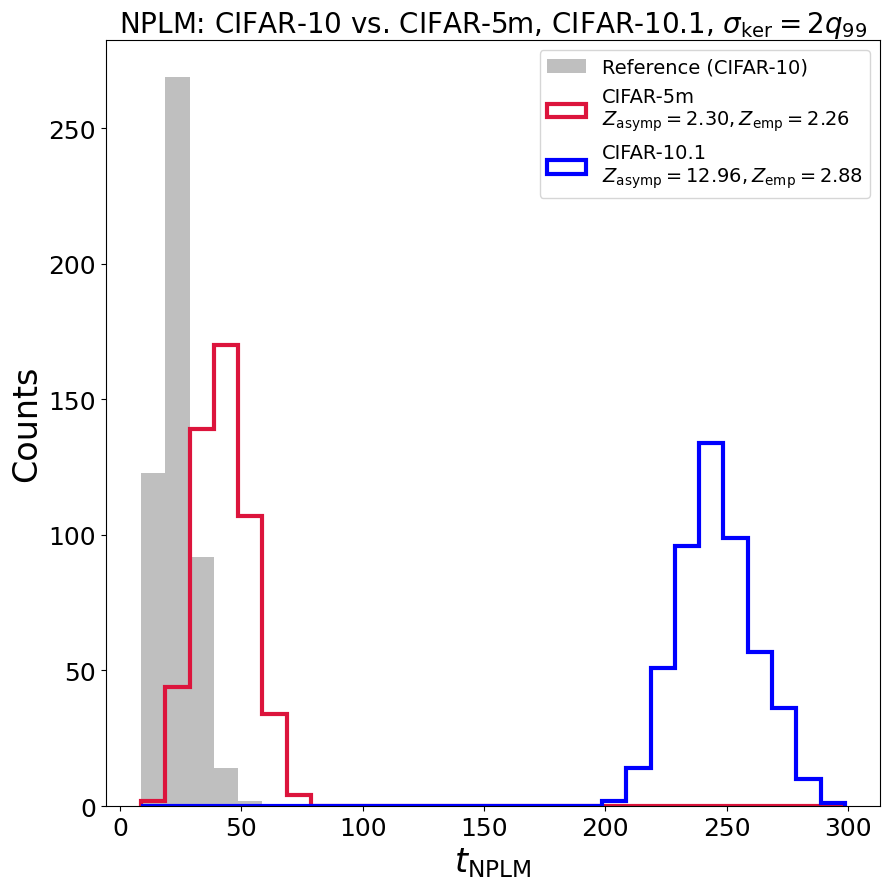

In [13]:
for i,sigma in enumerate(flk_sigmas):
    plt.figure(figsize=(9,9))
    tref = tstat_dict['ref'][:,i]
    t5m = tstat_dict['5m'][:,i]
    t101 = tstat_dict['101'][:,i]
    
    tref[np.isnan(tref)] = 0
    t5m[np.isnan(t5m)] = 0
    t101[np.isnan(t101)] = 0

    z_as_5m, z_emp_5m = nplm.get_zScores(tref, t5m, df=np.mean(tref))
    z_as_101, z_emp_101 = nplm.get_zScores(tref, t101, df=np.mean(tref))
    
    bins = np.arange(tref.min(),t101.max()+10,10)
    href = plt.hist(tref,bins=bins,color="gray",alpha=0.5,label="Reference (CIFAR-10)")
    h5m = plt.hist(t5m,bins=bins,color="crimson",alpha=1,histtype='step',label=f"CIFAR-5m\n$Z_\\text{{asymp}} = {z_as_5m[0]:.2f}, Z_\\text{{emp}} = {z_emp_5m[0]:.2f}$",lw=3)
    href = plt.hist(t101,bins=bins,color="blue",alpha=1,histtype='step',label=f"CIFAR-10.1\n$Z_\\text{{asymp}} = {z_as_101[0]:.2f}, Z_\\text{{emp}} = {z_emp_101[0]:.2f}$",lw=3)
    if i==0:
        plt.legend(fontsize=14,loc='upper right')
        plt.ylim([None,145])
    else:
        plt.legend(fontsize=14)
    plt.xlabel("$t_\\text{NPLM}$",fontsize=24)
    plt.xticks(fontsize=18)
    plt.ylabel("Counts",fontsize=24)
    plt.yticks(fontsize=18)
    
    sigma_label = plotting.kernel_to_label[sigma]
    #plt.title(f"NPLM: CIFAR-10 vs. CIFAR-5m, CIFAR-10.1, $\sigma_\\text{{ker}} = {sigma:.1f}$ ",fontsize=20)
    plt.title(f"NPLM: CIFAR-10 vs. CIFAR-5m, CIFAR-10.1, {sigma_label}",fontsize=20)
    plt.tight_layout()
    plt.savefig(f"cifar_plots/cifar10_vs_cifar5m_cifar10.1_kernel{sigma}.pdf",bbox_inches='tight')

In [65]:
f1 = "/n/home11/sambt/phlab-neurips25/experiments/cifar10/embeddings_noShift_spaceWithClassifier/cifar_allClasses/cifar10_test.npz"
f2 = "/n/home11/sambt/phlab-neurips25/experiments/cifar10/embeddings_noShift_spaceWithClassifier/cifar_allClasses/cifar10.1.npz"
f3 = "/n/home11/sambt/phlab-neurips25/experiments/cifar10/embeddings_noShift_spaceWithClassifier/cifar_allClasses/cifar5m_N100000.npz"
d1 = np.load(f1)
d2 = np.load(f2)
d3 = np.load(f3)

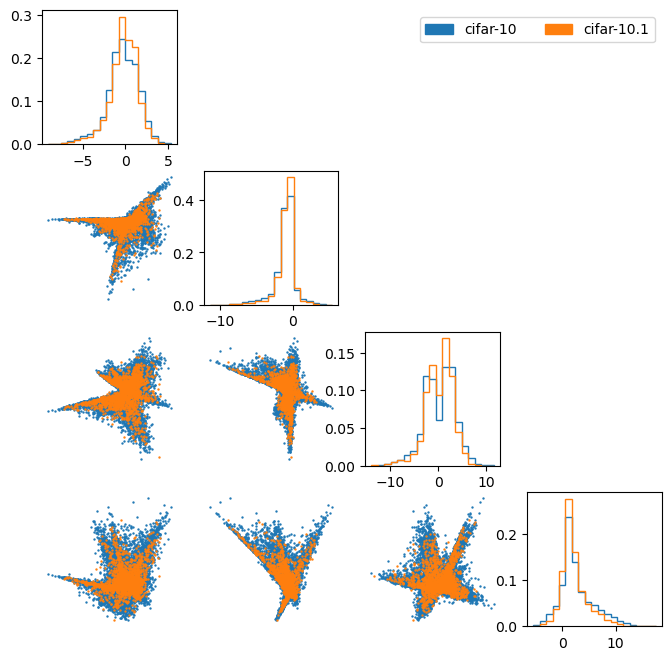

In [62]:
make_corner(np.concatenate([d1['data'],d2['data']]),labels=np.concatenate([np.zeros(len(d1['data'])),np.ones(len(d2['data']))]),label_names={0:"cifar-10",1:"cifar-10.1"})

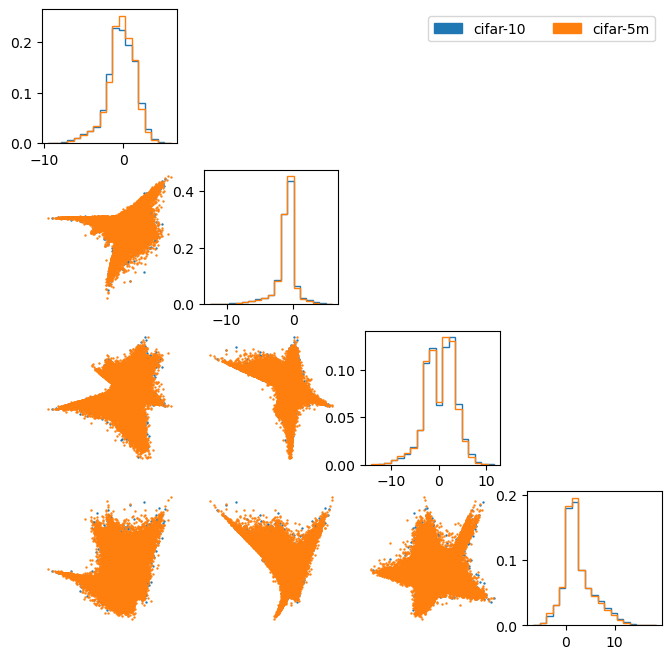

In [72]:
make_corner(np.concatenate([d1['data'],d3['data']]),labels=np.concatenate([np.zeros(len(d1['data'])),np.ones(len(d3['data']))]),label_names={0:"cifar-10",1:"cifar-5m"})

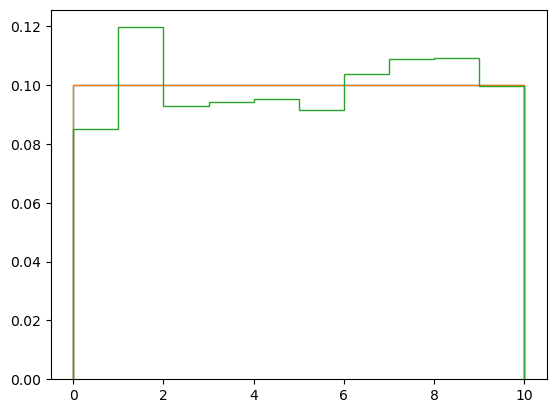

In [73]:
bins = np.arange(11)
h=plt.hist(d1['labels'],bins=bins,histtype='step',density=True)
h=plt.hist(d2['labels'],bins=bins,histtype='step',density=True)
h=plt.hist(d3['labels'],bins=bins,histtype='step',density=True)

In [81]:
d3_labels = d3['labels']
labels = sorted(list(set(d3_labels)))
min_ct = np.min([np.count_nonzero(d3_labels == l) for l in labels])
balanced_data = np.concatenate([d3['data'][d3['labels'] == l][:min_ct] for l in labels])
balanced_labels = np.concatenate([d3['labels'][d3['labels'] == l][:min_ct] for l in labels])
shuf = np.random.permutation(len(balanced_data))
balanced_data = balanced_data[shuf]
balanced_labels = balanced_labels[shuf]
np.savez("/n/home11/sambt/phlab-neurips25/experiments/cifar10/embeddings_noShift_spaceWithClassifier/cifar_allClasses/cifar5m_balancedLabels.npz",data=balanced_data,labels=balanced_labels)

In [84]:
from scipy.stats import norm

In [93]:
1/(1-norm.cdf(4))

31574.385534647936